# XGBoost Workflow

This notebook tests XGBoost on the same frozen curated feature set used by the finalized logistic model and the Random Forest workflow. All tuning stays on **train + validation only**. The later final section reports the already-frozen hold-out test evaluation and should not be treated as a tuning loop.

This notebook follows the same audited modeling scope as the logistic and Random Forest notebooks: fights before `2010-01-01` are excluded from the predictive workflow because the older source appears to mix corner assignment with winner listing.



In [1]:
from pathlib import Path
import json
import pandas as pd

repo_root = Path.cwd()
if repo_root.name == 'notebooks':
    repo_root = repo_root.parent
outputs_dir = repo_root / 'outputs'


## Why XGBoost

Boosting is worth testing because it can capture nonlinear relationships and interactions more aggressively than logistic regression, while usually learning more efficiently than bagged trees.

Compared with Random Forest:
- Random Forest averages many independently grown trees
- XGBoost builds trees sequentially, with each new tree trying to fix the previous mistakes
- that often gives stronger predictive signal, but also makes careful validation more important


In [2]:
xgb_results = pd.read_csv(outputs_dir / 'xgboost_validation_results.csv')
xgb_best = json.loads((outputs_dir / 'best_xgboost_validation.json').read_text())
xgb_importance = pd.read_csv(outputs_dir / 'xgboost_feature_importance.csv')
rf_baseline = json.loads((outputs_dir / 'random_forest_baseline_validation.json').read_text())
rf_best = json.loads((outputs_dir / 'best_random_forest_random_search.json').read_text())
final_logistic = json.loads((outputs_dir / 'final_logistic_test_metrics.json').read_text()) if (outputs_dir / 'final_logistic_test_metrics.json').exists() else None


## Validation-Only Tuning

If the full hyperparameter grid is too large, randomized search is a better fit than exhaustive grid search. Here we use 100 sampled configurations and rank them by validation log loss.


In [3]:
xgb_results.head(10)


,iteration,log_loss,roc_auc,brier_score,accuracy,subsample,reg_lambda,reg_alpha,n_estimators,min_child_weight,max_depth,learning_rate,colsample_bytree
0,61,0.681983,0.613939,0.243929,0.588829,0.85,5,0.0,300,5,2,0.01,1.00
1,43,0.682471,0.613869,0.243837,0.588829,0.70,10,0.0,500,3,2,0.01,0.70
2,52,0.682492,0.612901,0.244148,0.588053,0.85,3,0.1,100,5,2,0.03,0.70
3,13,0.682748,0.613162,0.244032,0.588829,0.85,10,1.0,300,1,3,0.01,0.85
4,63,0.683266,0.612688,0.244175,0.590380,0.85,5,0.0,500,3,2,0.01,1.00
5,69,0.683266,0.610919,0.244244,0.589604,1.00,5,0.1,100,1,2,0.05,0.70
6,98,0.683305,0.609943,0.244524,0.587277,1.00,3,0.1,300,3,2,0.01,0.70
7,53,0.683534,0.611360,0.243981,0.586501,0.70,5,0.1,300,1,5,0.01,1.00
8,58,0.683559,0.612349,0.244127,0.590380,0.85,3,1.0,300,1,4,0.01,1.00
9,7,0.683658,0.611613,0.244157,0.588829,0.85,3,0.1,300,5,4,0.01,1.00


## Best XGBoost Parameters


In [4]:
xgb_best['best_parameters']


{'objective': 'binary:logistic',
 'eval_metric': 'logloss',
 'random_state': 42,
 'n_jobs': -1,
 'verbosity': 0,
 'subsample': 0.85,
 'reg_lambda': 5,
 'reg_alpha': 0,
 'n_estimators': 300,
 'min_child_weight': 5,
 'max_depth': 2,
 'learning_rate': 0.01,
 'colsample_bytree': 1.0}

## Validation Comparison

This compares the XGBoost baseline, tuned XGBoost, Random Forest baseline, tuned Random Forest, and the validation-only logistic benchmark.


In [5]:
comparison = pd.DataFrame([
    {'model': 'xgb_baseline', **xgb_best['xgboost_baseline_validation_metrics']},
    {'model': 'xgb_tuned_best', **xgb_best['best_validation_metrics']},
    {'model': 'rf_baseline', **rf_baseline['validation_metrics']},
    {'model': 'rf_tuned_best', **rf_best['best_validation_metrics']},
    {'model': 'logistic_validation_benchmark', **xgb_best['logistic_validation_benchmark']},
])
comparison


,model,log_loss,roc_auc,brier_score,accuracy
0,xgb_baseline,0.694907,0.601687,0.247678,0.582622
1,xgb_tuned_best,0.681983,0.613939,0.243929,0.588829
2,rf_baseline,0.680929,0.614647,0.243385,0.592708
3,rf_tuned_best,0.667603,0.611137,0.237246,0.605120
4,logistic_validation_benchmark,0.662819,0.642413,0.235524,0.605896


## Feature Importance

XGBoost importance is model-specific rather than causal, but it helps show which features the tuned booster relied on most.


In [6]:
xgb_importance.head(12)


,feature,importance
0,diff_age,0.206785
1,diff_total_losses,0.131640
2,diff_reach,0.114893
3,diff_kd_absorbed_per_fight,0.080752
4,diff_win_streak,0.076557
5,diff_td_landed_per_fight,0.072656
6,diff_sig_strike_accuracy,0.069570
7,diff_total_wins,0.065847
8,pre_fight_red_late_finish_rate,0.063925
9,diff_five_round_experience,0.047683


## Hold-Out Safety

The XGBoost search itself was validation-only. The final section below shows the one-time hold-out benchmark for the frozen XGBoost model after selection was complete.


## Final XGBoost Test Evaluation

The best validation-selected XGBoost model has now been fit on train+validation and evaluated once on the hold-out test set. These are final benchmark results, not a new tuning step.

So these final XGBoost metrics should be read as the frozen 2010+ benchmark for this model family.



In [7]:
xgb_final = json.loads((outputs_dir / 'final_xgboost_test_metrics.json').read_text())
xgb_final


{'feature_names': ['diff_age',
  'diff_total_wins',
  'diff_total_losses',
  'diff_win_streak',
  'diff_td_landed_per_fight',
  'diff_kd_absorbed_per_fight',
  'diff_reach',
  'diff_sig_strike_accuracy',
  'diff_avg_fight_duration_seconds',
  'diff_decision_rate',
  'pre_fight_red_late_finish_rate',
  'diff_five_round_experience'],
 'model_params': {'objective': 'binary:logistic',
  'eval_metric': 'logloss',
  'random_state': 42,
  'n_jobs': -1,
  'verbosity': 0,
  'subsample': 0.85,
  'reg_lambda': 5,
  'reg_alpha': 0,
  'n_estimators': 300,
  'min_child_weight': 5,
  'max_depth': 2,
  'learning_rate': 0.01,
  'colsample_bytree': 1.0},
 'test_metrics': {'log_loss': 0.6883890817967879,
  'roc_auc': 0.6359410425334622,
  'brier_score': 0.24737323820590973,
  'accuracy': 0.5655546935608999,
  'precision': 0.5582722086389568,
  'recall': 0.9743954480796586,
  'f1': 0.7098445595854922},
 'confusion_matrix': {'labels': [0, 1],
  'matrix': [[44, 542], [18, 685]],
  'tn': 44,
  'fp': 542,
  '

In [8]:
final_model_comparison = pd.read_csv(outputs_dir / 'final_model_test_comparison.csv')
final_model_comparison


            model_name  ...                                              notes
0  logistic_regression  ...  Best log loss on test. Best ROC AUC on test. B...
1        random_forest  ...                             Best accuracy on test.
2              xgboost  ...  Highest recall on test. Weakest overall probab...

[3 rows x 14 columns]

In [9]:
xgb_calibration = pd.read_csv(outputs_dir / 'final_xgboost_calibration_table.csv')
xgb_importance_final = pd.read_csv(outputs_dir / 'final_xgboost_feature_importance.csv')
xgb_calibration


,probability_bin,rows,mean_predicted_probability,observed_red_win_rate
0,0,129,0.493918,0.372093
1,1,129,0.564571,0.341085
2,2,129,0.605859,0.465116
3,3,129,0.637316,0.534884
4,4,129,0.663986,0.511628
5,5,128,0.680536,0.601562
6,6,129,0.689956,0.612403
7,7,129,0.702953,0.589147
8,8,129,0.717432,0.697674
9,9,129,0.744670,0.728682


In [10]:
xgb_importance_final.head(12)


,feature,importance
0,diff_age,0.182348
1,diff_total_losses,0.166891
2,diff_kd_absorbed_per_fight,0.089287
3,diff_sig_strike_accuracy,0.089245
4,diff_win_streak,0.088905
5,diff_reach,0.088017
6,diff_td_landed_per_fight,0.075356
7,diff_total_wins,0.072788
8,pre_fight_red_late_finish_rate,0.059913
9,diff_decision_rate,0.032257


## Final XGBoost Visuals

These plots summarize the frozen XGBoost benchmark and place it next to the other final model families without reopening tuning.


In [11]:
import matplotlib.pyplot as plt
from pathlib import Path
import pandas as pd

repo_root = Path.cwd()
if repo_root.name == 'notebooks':
    repo_root = repo_root.parent
figures_dir = repo_root / 'outputs' / 'figures'
figures_dir.mkdir(parents=True, exist_ok=True)

xgb_importance_final = pd.read_csv(repo_root / 'outputs' / 'final_xgboost_feature_importance.csv')
final_model_comparison = pd.read_csv(repo_root / 'outputs' / 'final_model_test_comparison.csv')


### XGBoost Feature Importance

Like the Random Forest importances, these are model-specific rankings that show which inputs the frozen booster leaned on most.


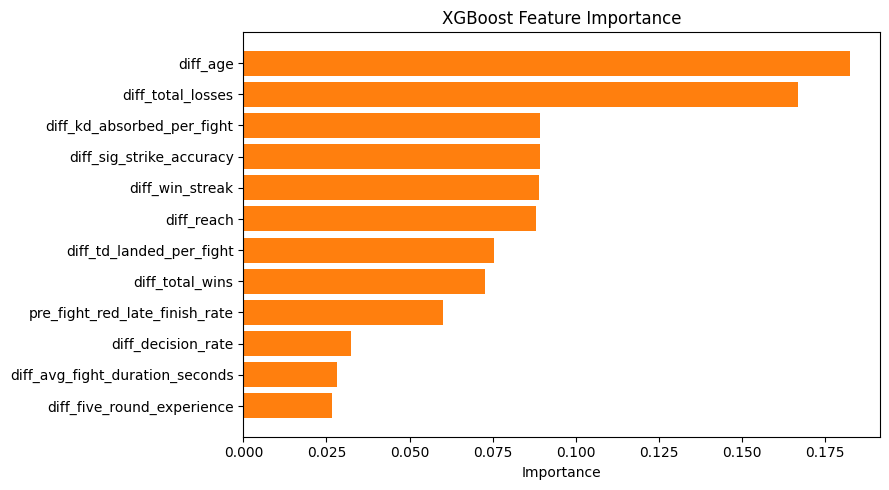

In [12]:
plot_df = xgb_importance_final.head(12).sort_values('importance')
fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(plot_df['feature'], plot_df['importance'], color='tab:orange')
ax.set_title('XGBoost Feature Importance')
ax.set_xlabel('Importance')
fig.tight_layout()
fig.savefig(figures_dir / '05_xgboost_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()


### Brief Comparison To Logistic And Random Forest

This bar chart keeps the tree-model comparison grounded in the same final hold-out benchmark table. Lower log loss is better; higher ROC AUC is better.


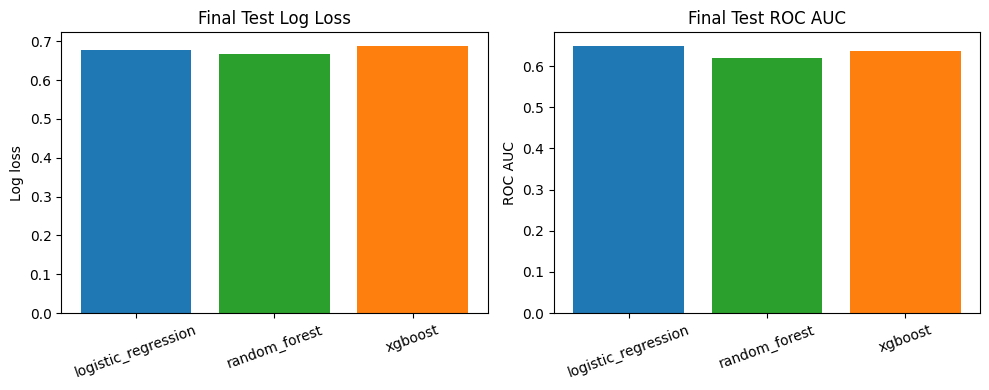

In [13]:
comparison = final_model_comparison.set_index('model_name').loc[['logistic_regression', 'random_forest', 'xgboost']]
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].bar(comparison.index, comparison['log_loss'], color=['tab:blue', 'tab:green', 'tab:orange'])
axes[0].set_title('Final Test Log Loss')
axes[0].set_ylabel('Log loss')
axes[0].tick_params(axis='x', rotation=20)
axes[1].bar(comparison.index, comparison['roc_auc'], color=['tab:blue', 'tab:green', 'tab:orange'])
axes[1].set_title('Final Test ROC AUC')
axes[1].set_ylabel('ROC AUC')
axes[1].tick_params(axis='x', rotation=20)
fig.tight_layout()
fig.savefig(figures_dir / '05_xgboost_vs_rf_logistic.png', dpi=150, bbox_inches='tight')
plt.show()


## Position In The Broader Research Pipeline

XGBoost remains a useful nonlinear benchmark in this repo, but it was not the probability model carried forward into the newer walk-forward market-benchmark research track. That later workflow focuses on the Random Forest family because it was the strongest probability-oriented tree benchmark at the final hold-out stage and the model used in the first betting backtest.


In [ ]:
walk_forward_comparison = pd.read_csv(outputs_dir / "walk_forward_model_comparison.csv")
walk_forward_comparison.head(10)


That split is intentional: this notebook documents XGBoost as a tested model family, while the walk-forward notebook documents the next research stage around calibration, market baselines, and blended probabilities.
